In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random
import numpy as np
from sklearn.model_selection import StratifiedKFold

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
# Seed 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
# GPU 사용 가능 여부 확인
print(f"GPU 사용 가능 여부: {torch.cuda.is_available()}")

# 사용 가능한 GPU 개수 및 이름 확인
if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

GPU 사용 가능 여부: True
GPU 개수: 1
현재 GPU 이름: NVIDIA TITAN Xp


In [4]:
# 하이퍼파라미터 설정
BATCH_SIZE  = 32
EPOCHS      = 10   
LR          = 0.001
NUM_CLASSES = 2
N_SPLITS    = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import glob 
import os 

# 경로 지정 
root='./'
image_folder_path = os.path.join(root, 'product_images') 

# images 폴더가 없으면 생성(이미 존재하면 건너뜀)
if not os.path.exists(image_folder_path):
    os.makedirs(image_folder_path)

import kaggle
kaggle.api.dataset_download_files('ravirajsinh45/real-life-industrial-dataset-of-casting-product', path=image_folder_path, unzip=True)

print(image_folder_path)
print(glob.glob(image_folder_path+'/*')) 

Dataset URL: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
./product_images
['./product_images/casting_data', './product_images/casting_512x512']


In [6]:
TRAIN_DIR = os.path.join(image_folder_path, "casting_data", "casting_data","train")
TEST_DIR = os.path.join(image_folder_path, "casting_data", "casting_data", "test")

print("Train 경로:", TRAIN_DIR)
print("TEST 경로:", TEST_DIR)

Train 경로: ./product_images/casting_data/casting_data/train
TEST 경로: ./product_images/casting_data/casting_data/test


In [7]:
# VGGNet 19-layer (VGG-19) 정의 
class VGG19(nn.Module):
    def __init__(self, num_classes=2):
        super(VGG19, self).__init__()

        # Convolution + ReLU layers (3x3 convolution, padding=1)
        # nn.Sequential는 "레이어를 순서대로 담는 상자"이다.

        self.features = nn.Sequential(
            # Block 1 : 2 conv layers + maxpool
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 2 conv layers + maxpool
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 4 conv layers + maxpool
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4 : 4 conv layers + maxpool
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5 : 4 conv layers + maxpool
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully Connected layers
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096), # 입력 크기 : 마지막 feature map 7x7
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

    def forward(self,x):
        x=self.features(x) # Convolution & Pooling
        x=x.view(x.size(0),-1) # Flatten
        x=self.classifier(x) # Fully Connected Network
        return x
    

In [8]:
# # 데이터 전처리 & DataLoader
# train_transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(), # 좌우 반전(데이터 증강)
#     transforms.RandomRotation(10), # 10도 회전(데이터 증강)
#     transforms.ToTensor(), 
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 기준 정규화
# ])

# 데이터 전처리 & DataLoader
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(), # 좌우 반전(데이터 증강)
    transforms.RandomVerticalFlip(), # 상하 반전 추가
    transforms.RandomRotation(10), # 10도 회전(데이터 증강)
    transforms.RandomAffine( # Height/Width Shift 추가
        degrees=0,
        translate=(0.1, 0.1)                    
    ),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet 기준 정규화
    transforms.Lambda(
        lambda x: x + 0.01 * torch.randn_like(x)  # Gaussian Noise 추가
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 10-fold CV를 위해 train + test 전체 합치기
train_folder_train_tf = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_folder_train_tf  = datasets.ImageFolder(TEST_DIR,  transform=train_transform)
full_dataset_train_tf = ConcatDataset([train_folder_train_tf, test_folder_train_tf])

train_folder_val_tf   = datasets.ImageFolder(TRAIN_DIR, transform=val_transform)
test_folder_val_tf    = datasets.ImageFolder(TEST_DIR,  transform=val_transform)
full_dataset_val_tf   = ConcatDataset([train_folder_val_tf, test_folder_val_tf])

all_targets = np.array(
    train_folder_train_tf.targets + test_folder_train_tf.targets
)

print(f"클래스 : {train_folder_train_tf.classes}")
print(f"전체 데이터 수: {len(all_targets)}")

클래스 : ['def_front', 'ok_front']
전체 데이터 수: 7348


In [9]:
# # loss 함수 & optimizer 설정 
# criterion = nn.CrossEntropyLoss() # softmax 내장 
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# # LR Scheduler : val_loss가 5 epoch 동안 개선이 없으면 LR을 절반으로 줄임 
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6 
# )

# # Early Stopping 설정 
# patience = 10 # 10 epoch 동안 개선 없으면 학습 중단 
# best_val_loss = float('inf')
# counter=0

# train 
def train(model, loader, criterion, optimizer):
    model.train() # 학습 모드
    total_loss, correct, total = 0,0,0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # gradient 초기화 
        outputs=model(images)
        loss=criterion(outputs, labels)
        loss.backward() 

        optimizer.step() # 가중치 업데이트 

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total

In [10]:
# test
def test(model, loader, criterion):
    model.eval() # 평가모드
    total_loss, correct, total = 0,0,0

    with torch.no_grad(): # gradient 계산 비활성화
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), 100. * correct / total


Fold [1/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장



Epoch [01/10]
  Train Loss: 1.5838 | Train Acc: 55.51%
  Val   Loss: 0.6828 | Val   Acc: 57.41%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7059 | Train Acc: 61.98%
  Val   Loss: 4.3401 | Val   Acc: 43.27%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.5519 | Train Acc: 79.80%
  Val   Loss: 0.4286 | Val   Acc: 85.17%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.3817 | Train Acc: 85.39%
  Val   Loss: 0.3344 | Val   Acc: 88.44%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.3830 | Train Acc: 85.86%
  Val   Loss: 0.4639 | Val   Acc: 74.56%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.4150 | Train Acc: 86.01%
  Val   Loss: 0.8841 | Val   Acc: 80.82%
--------------------------------------------------

Epoch [07/10]
  Train Loss: 0.3585 | Train Acc: 86.39%
  Val   Loss: 0.2317 | Val   Acc: 91.29%
---------------

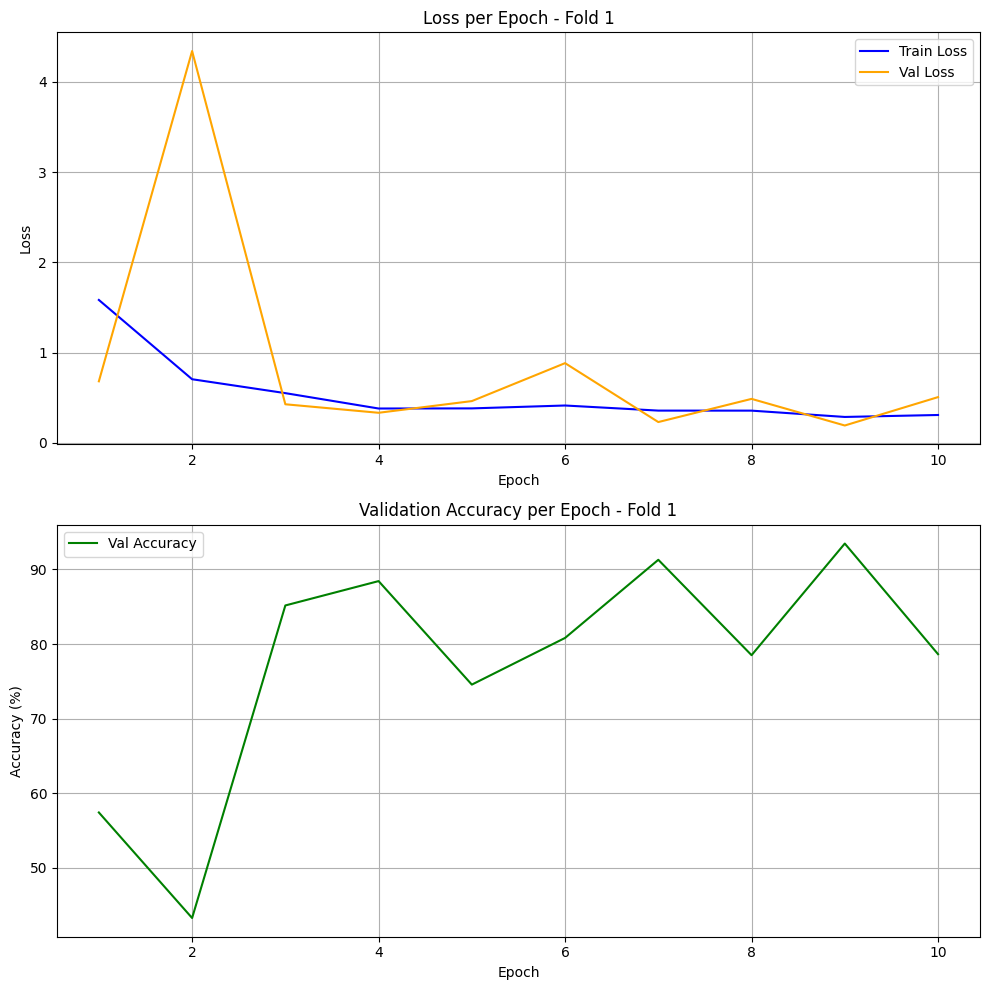


Fold [2/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.5809 | Train Acc: 61.05%
  Val   Loss: 0.8804 | Val   Acc: 72.93%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.5590 | Train Acc: 76.82%
  Val   Loss: 0.4843 | Val   Acc: 79.86%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.4473 | Train Acc: 82.37%
  Val   Loss: 0.4128 | Val   Acc: 89.39%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.4015 | Train Acc: 85.32%
  Val   Loss: 0.4566 | Val   Acc: 80.27%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.3710 | Train Acc: 85.26%
  Val   Loss: 0.2337 | Val   Acc: 92.24%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.3103 | Train Acc: 88.14%
  Val   Loss: 0.2445 | Val   Acc: 91.29%
--------------------------------------------------

Epoch [07/10]
  Trai

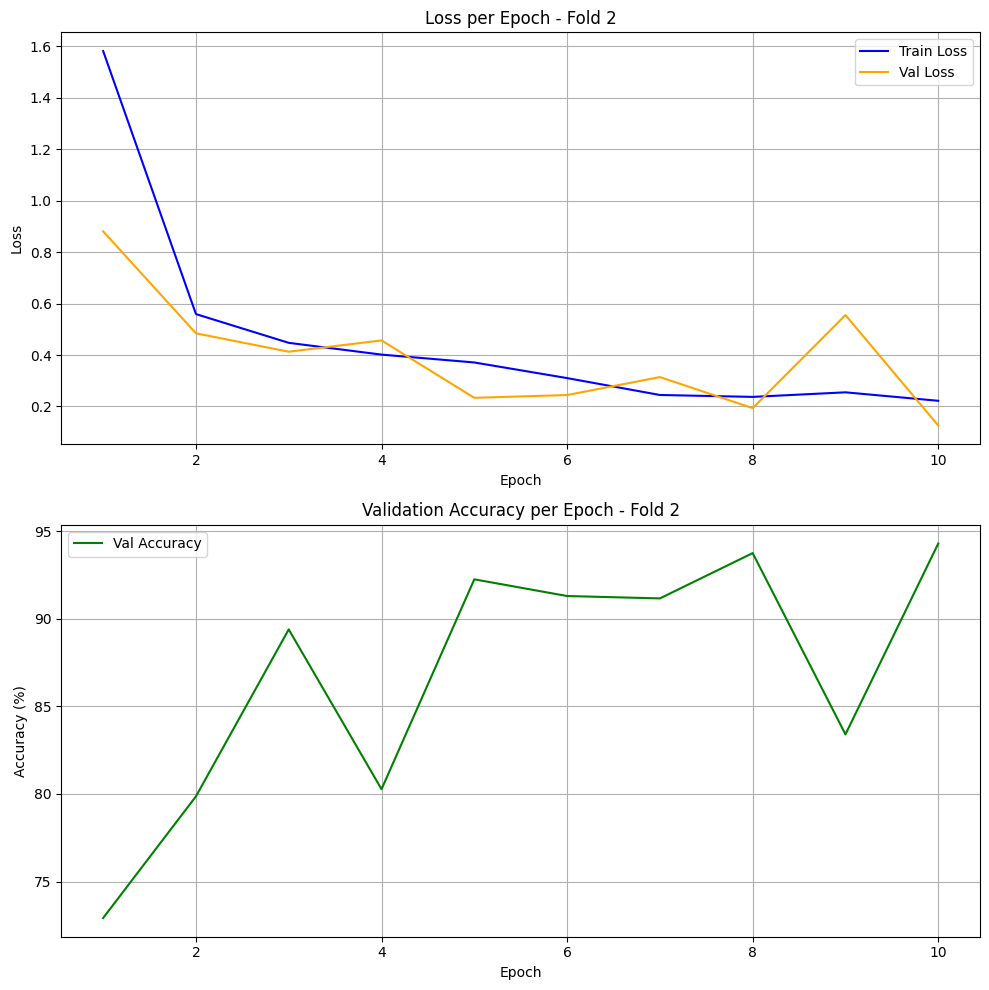


Fold [3/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.6099 | Train Acc: 57.31%
  Val   Loss: 0.7007 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7219 | Train Acc: 56.33%
  Val   Loss: 0.6907 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.6871 | Train Acc: 60.34%
  Val   Loss: 1.0233 | Val   Acc: 49.39%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.7778 | Train Acc: 59.81%
  Val   Loss: 0.6746 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.6015 | Train Acc: 67.87%
  Val   Loss: 1.0539 | Val   Acc: 60.95%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.6327 | Train Acc: 67.10%
  Val   Loss: 0.6876 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [07/10]
  Trai

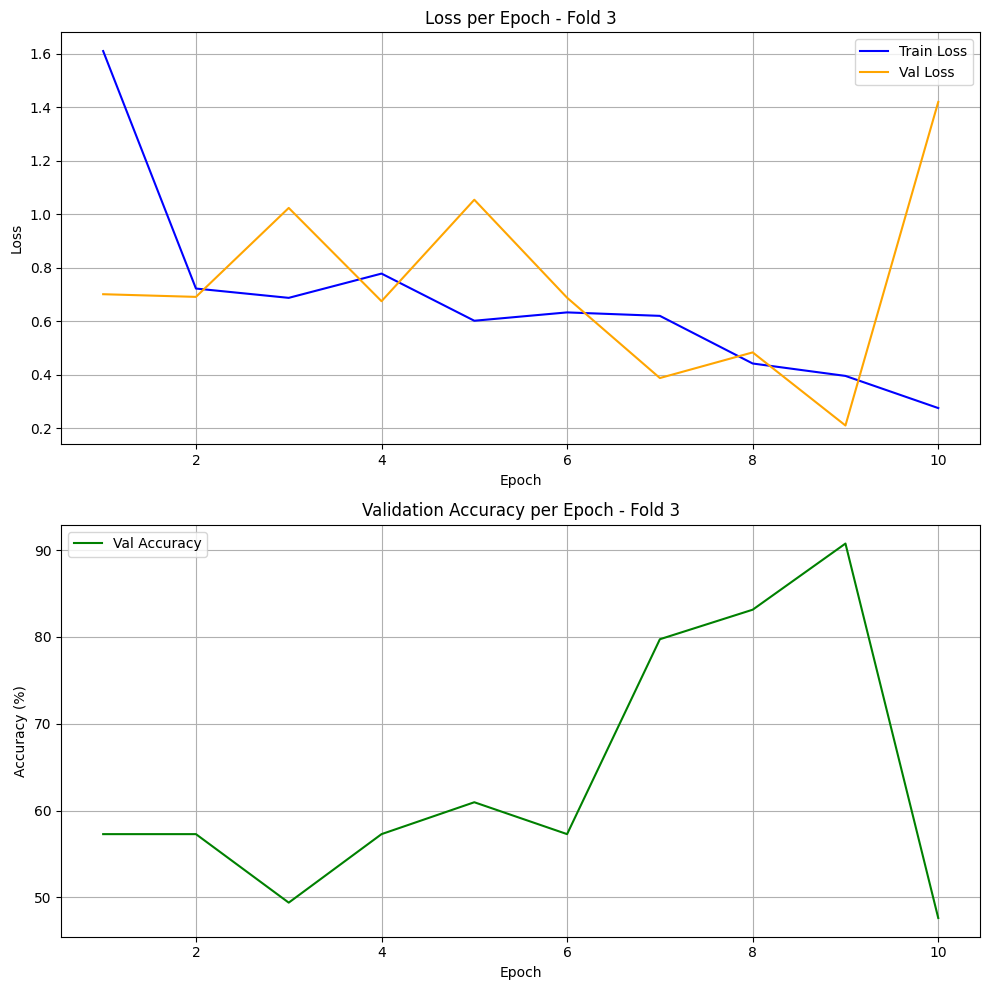


Fold [4/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.5997 | Train Acc: 55.60%
  Val   Loss: 0.6831 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7245 | Train Acc: 57.63%
  Val   Loss: 0.6875 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.6827 | Train Acc: 56.87%
  Val   Loss: 0.6857 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.6799 | Train Acc: 57.15%
  Val   Loss: 0.6791 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.6777 | Train Acc: 61.68%
  Val   Loss: 0.4644 | Val   Acc: 79.05%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.5026 | Train Acc: 77.33%
  Val   Loss: 0.2051 | Val   Acc: 93.20%
--------------------------------------------------

Epoch [07/10]
  Trai

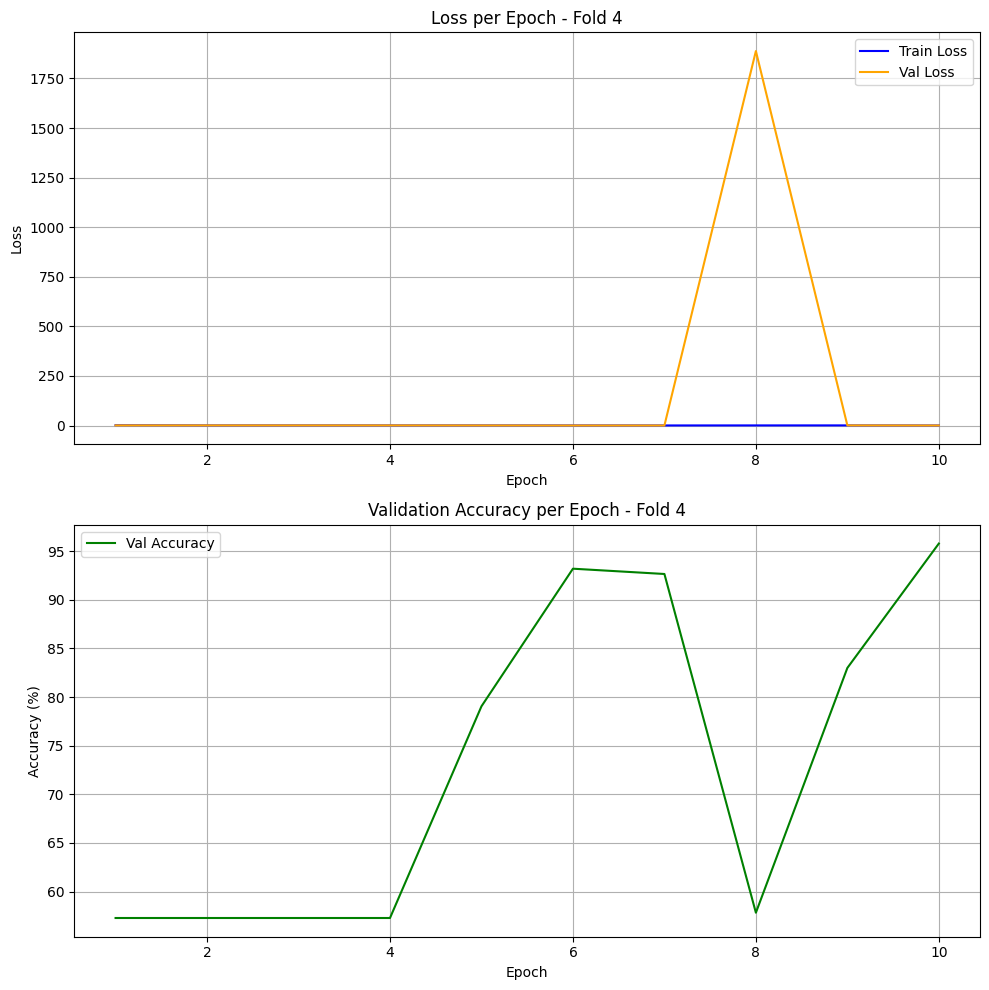


Fold [5/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.6936 | Train Acc: 54.41%
  Val   Loss: 0.6829 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.6952 | Train Acc: 56.74%
  Val   Loss: 0.6861 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.7101 | Train Acc: 57.07%
  Val   Loss: 0.6335 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.6369 | Train Acc: 74.28%
  Val   Loss: 0.9601 | Val   Acc: 77.69%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.5087 | Train Acc: 79.49%
  Val   Loss: 0.8478 | Val   Acc: 81.50%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.3856 | Train Acc: 86.54%
  Val   Loss: 0.2070 | Val   Acc: 91.56%
--------------------------------------------------

Epoch [07/10]
  Trai

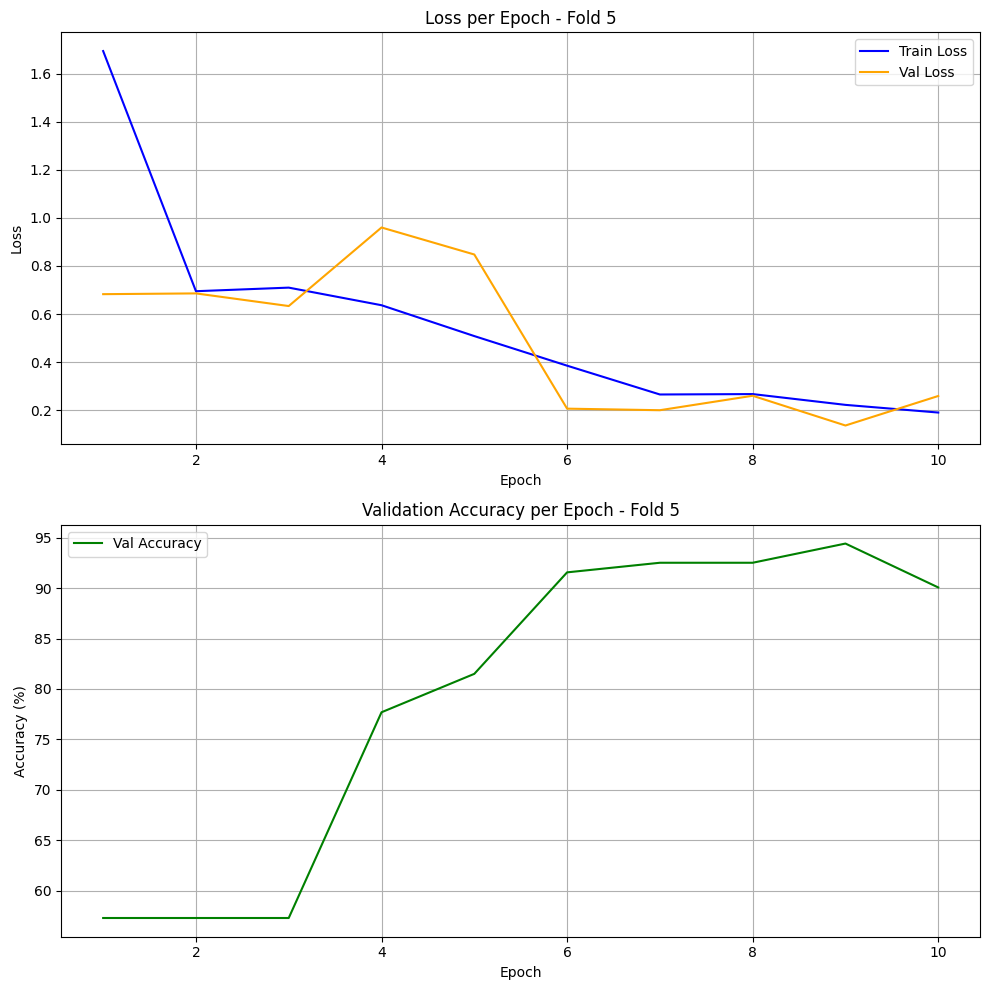


Fold [6/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.6171 | Train Acc: 54.47%
  Val   Loss: 0.6907 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7084 | Train Acc: 56.77%
  Val   Loss: 0.6877 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.6580 | Train Acc: 66.90%
  Val   Loss: 0.3335 | Val   Acc: 89.25%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.5622 | Train Acc: 77.17%
  Val   Loss: 0.3963 | Val   Acc: 88.71%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.4514 | Train Acc: 80.99%
  Val   Loss: 0.9907 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.3760 | Train Acc: 83.67%
  Val   Loss: 0.3424 | Val   Acc: 86.80%
--------------------------------------------------

Epoch [07/10]
  Trai

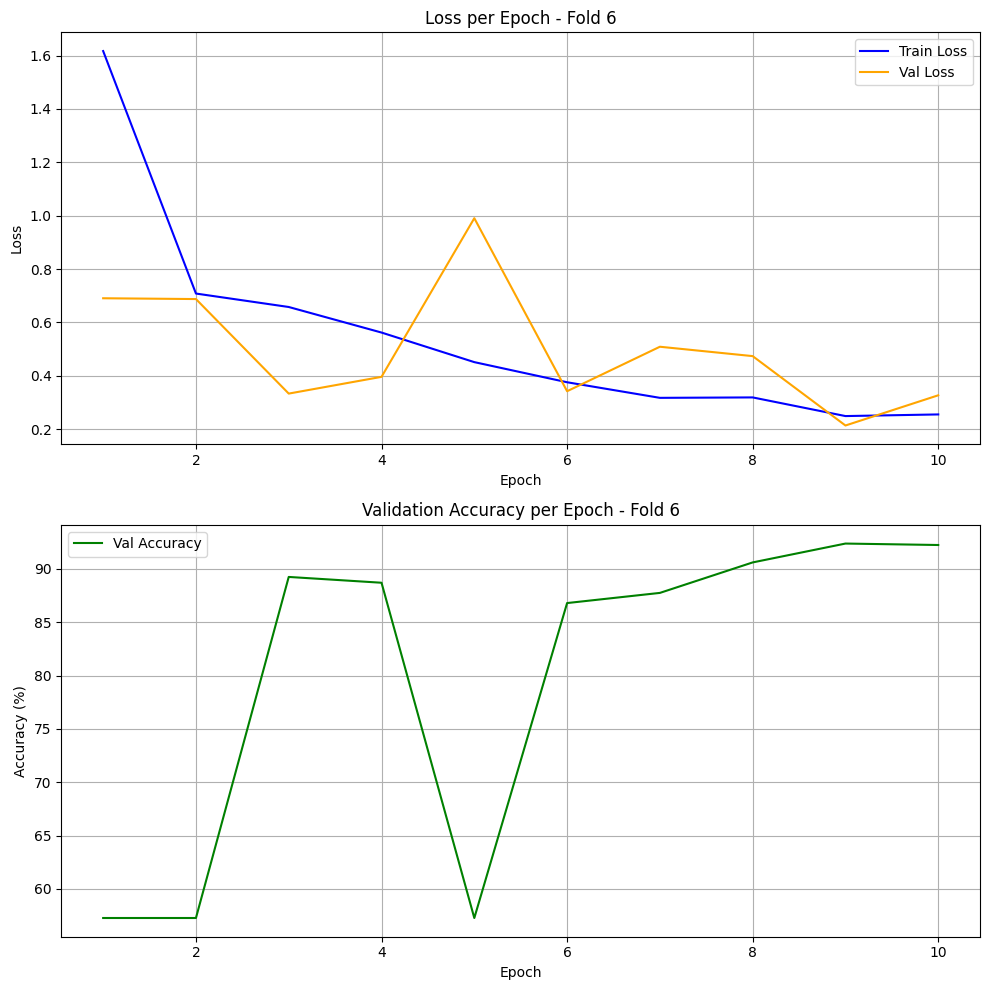


Fold [7/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.6004 | Train Acc: 54.76%
  Val   Loss: 0.6860 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7062 | Train Acc: 55.95%
  Val   Loss: 0.6865 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.6959 | Train Acc: 56.95%
  Val   Loss: 0.6849 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.6845 | Train Acc: 56.99%
  Val   Loss: 0.6831 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.6829 | Train Acc: 57.31%
  Val   Loss: 0.6827 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.6827 | Train Acc: 57.31%
  Val   Loss: 0.6827 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [07/10]
  Trai

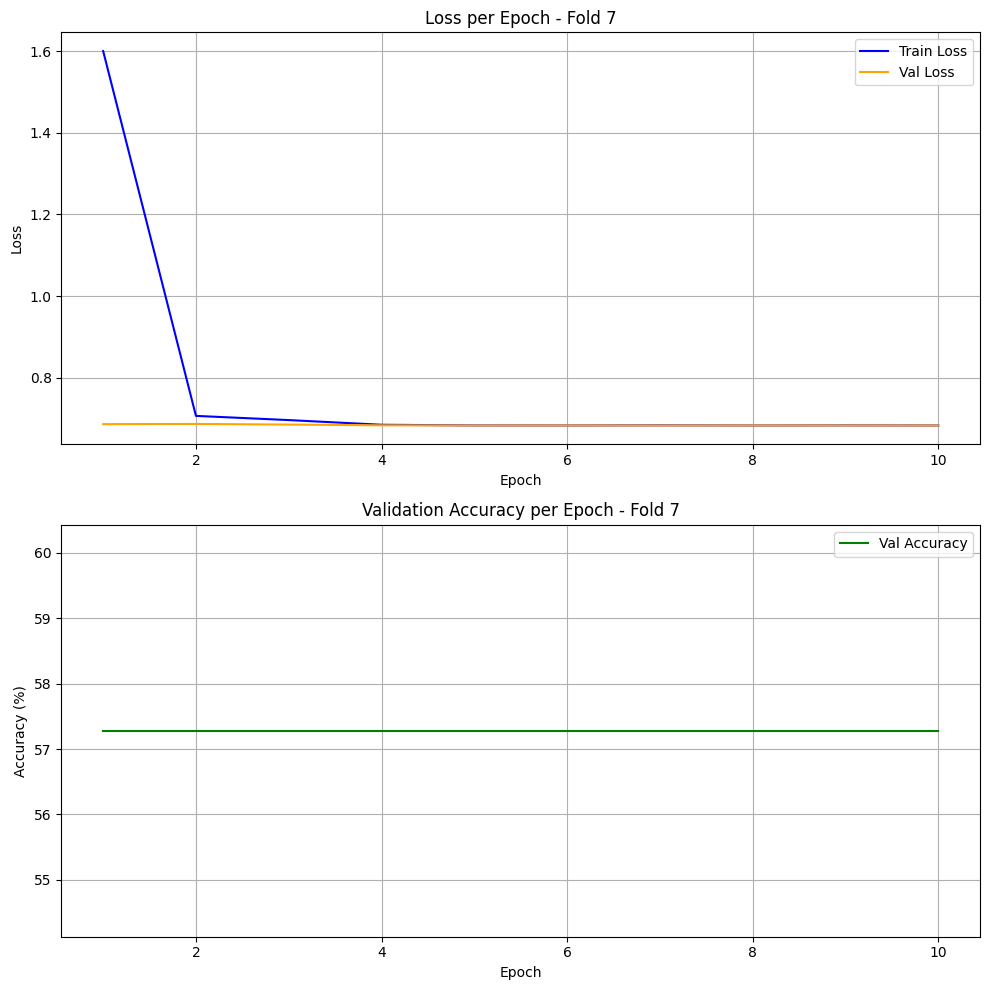


Fold [8/10]
--------------------------------------------------
  Train: 6613장 | Val: 735장

Epoch [01/10]
  Train Loss: 1.6482 | Train Acc: 54.47%
  Val   Loss: 0.6828 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.7081 | Train Acc: 55.66%
  Val   Loss: 0.6829 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.6881 | Train Acc: 57.24%
  Val   Loss: 0.6831 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.6867 | Train Acc: 57.36%
  Val   Loss: 0.6449 | Val   Acc: 66.39%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.7310 | Train Acc: 55.21%
  Val   Loss: 0.6826 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.6829 | Train Acc: 57.31%
  Val   Loss: 0.6828 | Val   Acc: 57.28%
--------------------------------------------------

Epoch [07/10]
  Trai

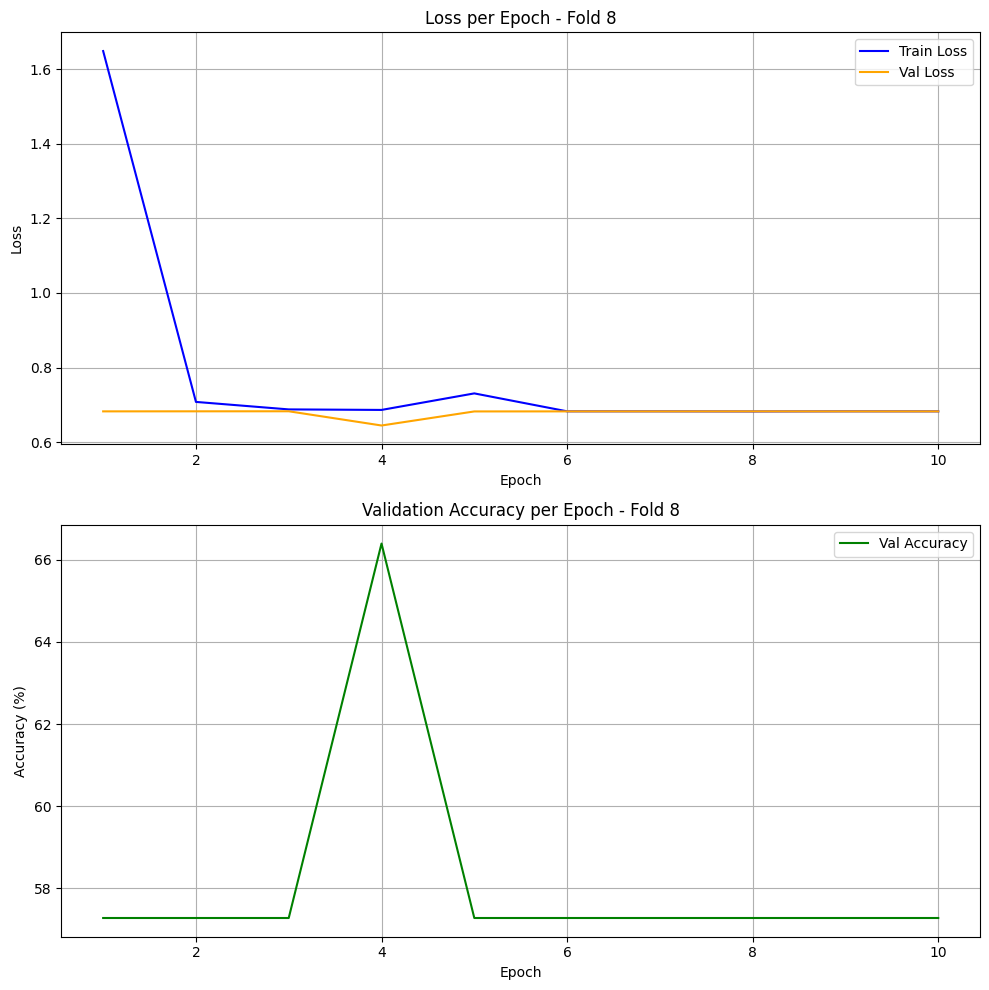


Fold [9/10]
--------------------------------------------------
  Train: 6614장 | Val: 734장

Epoch [01/10]
  Train Loss: 1.8216 | Train Acc: 71.83%
  Val   Loss: 0.3493 | Val   Acc: 85.56%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.3062 | Train Acc: 88.81%
  Val   Loss: 0.6977 | Val   Acc: 73.02%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.2656 | Train Acc: 90.47%
  Val   Loss: 0.1545 | Val   Acc: 94.69%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.2619 | Train Acc: 90.73%
  Val   Loss: 0.9317 | Val   Acc: 57.77%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.2148 | Train Acc: 92.91%
  Val   Loss: 0.5015 | Val   Acc: 78.34%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.2435 | Train Acc: 90.99%
  Val   Loss: 0.2151 | Val   Acc: 91.69%
--------------------------------------------------

Epoch [07/10]
  Trai

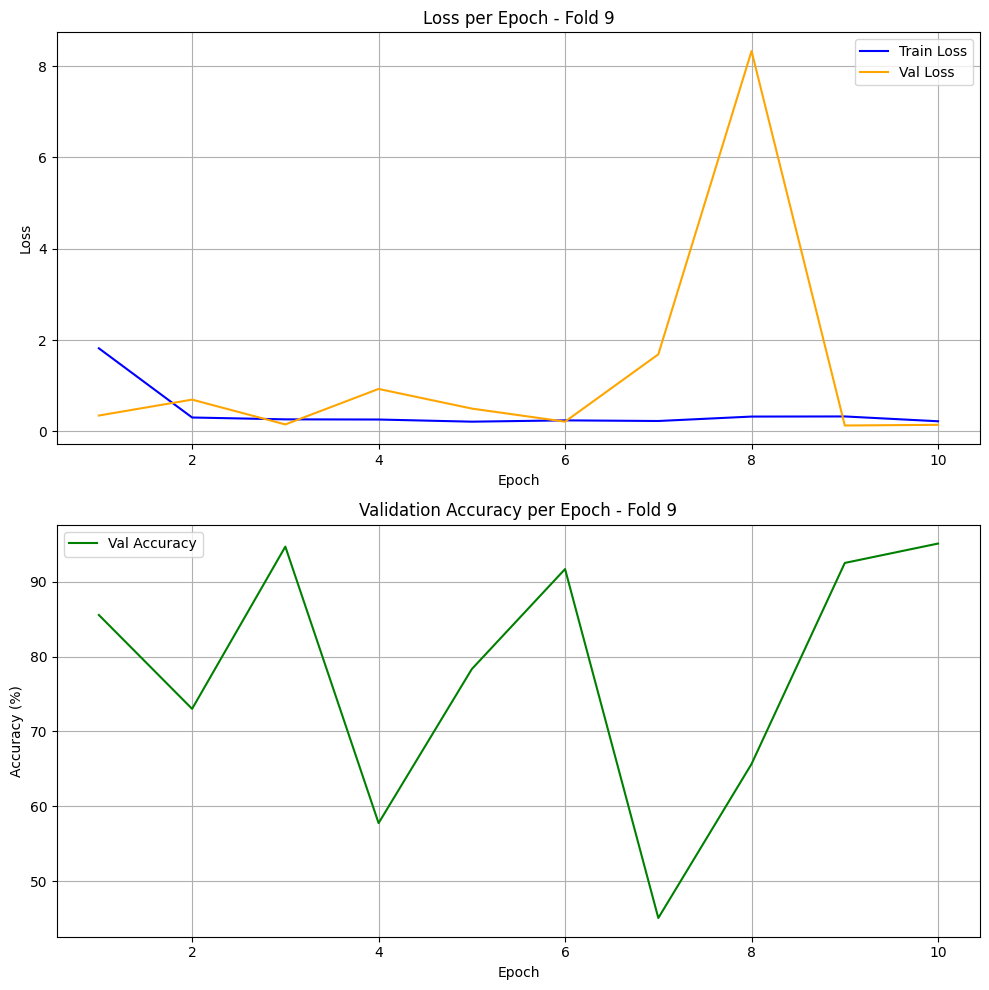


Fold [10/10]
--------------------------------------------------
  Train: 6614장 | Val: 734장

Epoch [01/10]
  Train Loss: 1.9698 | Train Acc: 58.97%
  Val   Loss: 0.6984 | Val   Acc: 53.13%
--------------------------------------------------

Epoch [02/10]
  Train Loss: 0.5445 | Train Acc: 74.55%
  Val   Loss: 1.8021 | Val   Acc: 46.32%
--------------------------------------------------

Epoch [03/10]
  Train Loss: 0.4278 | Train Acc: 81.90%
  Val   Loss: 0.2383 | Val   Acc: 90.19%
--------------------------------------------------

Epoch [04/10]
  Train Loss: 0.4079 | Train Acc: 82.75%
  Val   Loss: 1.1143 | Val   Acc: 76.98%
--------------------------------------------------

Epoch [05/10]
  Train Loss: 0.3523 | Train Acc: 85.32%
  Val   Loss: 0.2818 | Val   Acc: 86.38%
--------------------------------------------------

Epoch [06/10]
  Train Loss: 0.3495 | Train Acc: 85.24%
  Val   Loss: 0.2103 | Val   Acc: 92.64%
--------------------------------------------------

Epoch [07/10]
  Tra

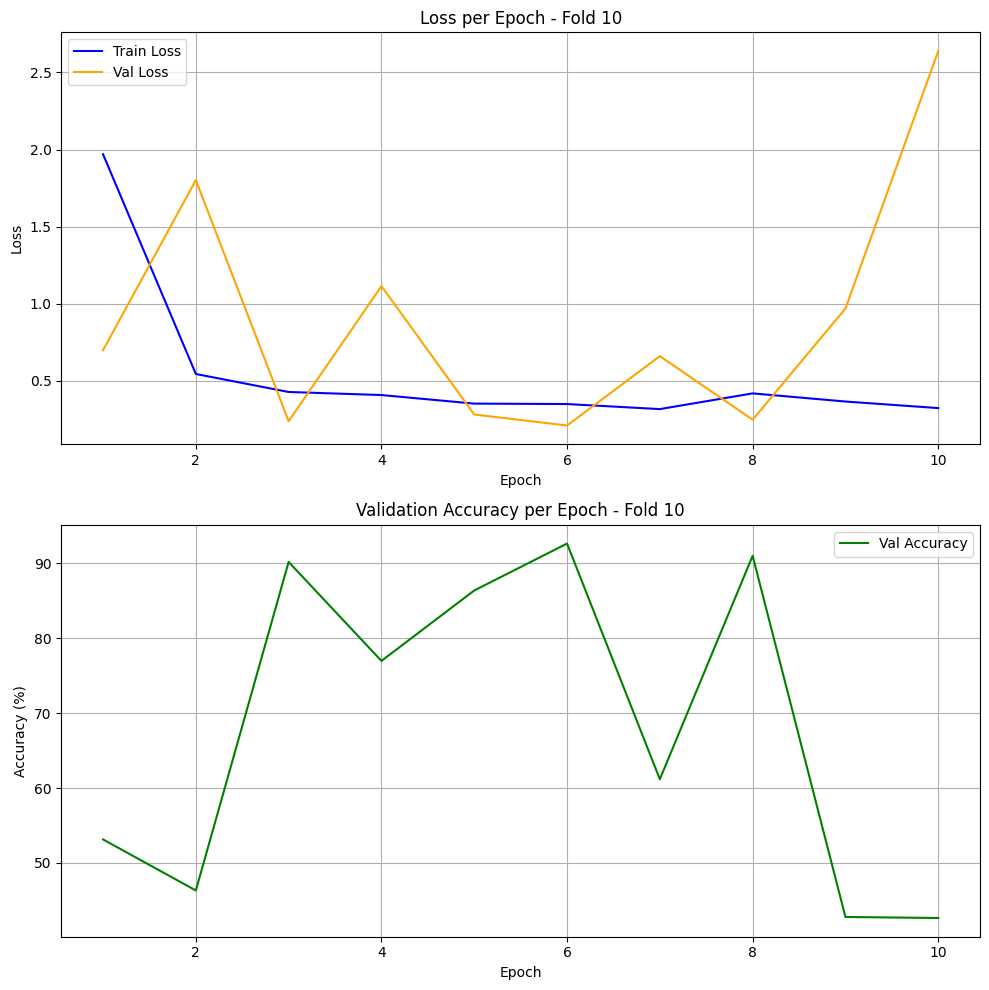

In [11]:
# 10-Fold Cross Validation

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_accs = []
all_fold_train_losses, all_fold_val_losses = [], []
all_fold_train_accs,   all_fold_val_accs   = [], []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(all_targets)), all_targets), 1):

    set_seed(42)

    print(f"\nFold [{fold}/{N_SPLITS}]")
    print("-" * 50)

    train_dataset = Subset(full_dataset_train_tf, train_idx)
    val_dataset   = Subset(full_dataset_val_tf,   val_idx)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    print(f"  Train: {len(train_dataset)}장 | Val: {len(val_dataset)}장")

    # fold마다 모델 새로 초기화
    model     = VGG19(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    fold_train_losses, fold_val_losses = [], []
    fold_train_accs,   fold_val_accs   = [], []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = test(model, val_loader, criterion)

        fold_train_losses.append(train_loss)
        fold_val_losses.append(val_loss)
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)

        print(f"\nEpoch [{epoch:02d}/{EPOCHS}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
        print("-" * 50)

    all_fold_train_losses.append(fold_train_losses)
    all_fold_val_losses.append(fold_val_losses)
    all_fold_train_accs.append(fold_train_accs)
    all_fold_val_accs.append(fold_val_accs)
    fold_accs.append(fold_val_accs[-1])

    # fold별 그래프
    epochs_range = range(1, EPOCHS + 1)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    ax1.plot(epochs_range, fold_train_losses, label="Train Loss", color='blue')
    ax1.plot(epochs_range, fold_val_losses,   label="Val Loss",   color='orange')
    ax1.set_title(f"Loss per Epoch - Fold {fold}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs_range, fold_val_accs, label="Val Accuracy", color='green')
    ax2.set_title(f"Validation Accuracy per Epoch - Fold {fold}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"vgg19_fold{fold}_result.png", dpi=150)
    plt.show()

In [12]:
# 최종 결과 출력
print("\n" + "=" * 50)
print("     VGG19 10-Fold CV 최종 결과")
print("=" * 50)
print(f"  Fold별 Accuracy: {[f'{acc:.2f}%' for acc in fold_accs]}")
print(f"  평균 Accuracy  : {np.mean(fold_accs):.2f}%")
print(f"  표준 편차      : {np.std(fold_accs):.2f}%")
print("=" * 50)
print(f"\n  [논문 결과 비교 - Casting dataset]")
print(f"  논문 VGG19 Accuracy : 87.39%")
print(f"  본 실험 Accuracy    : {np.mean(fold_accs):.2f}%")
print(f"  차이                : {np.mean(fold_accs) - 87.39:+.2f}%")
print("=" * 50)


     VGG19 10-Fold CV 최종 결과
  Fold별 Accuracy: ['78.64%', '94.29%', '47.62%', '95.78%', '90.07%', '92.24%', '57.28%', '57.28%', '95.10%', '42.64%']
  평균 Accuracy  : 75.09%
  표준 편차      : 20.42%

  [논문 결과 비교 - Casting dataset]
  논문 VGG19 Accuracy : 87.39%
  본 실험 Accuracy    : 75.09%
  차이                : -12.30%
